# 3. Exploratory Data Analysis

This notebook explores the distribution of 30-day readmission, patient characteristics, healthcare utilization, and encounter-level factors to identify patterns relevant to readmission risk and post-discharge resource prioritization.

## 3.1 Analysis Setup

The processed dataset is loaded for exploratory analysis. A binary target variable is created to distinguish encounters followed by readmission within 30 days from all other encounters.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load processed data
df = pd.read_csv("../data/processed/diabetic_data_mapped.csv")

# Create binary 30-day readmission target
df["readmitted_30d"] = (df["readmitted"] == "<30").astype(int)

# Viridis visual theme
cmap = plt.cm.viridis
colors = cmap(np.linspace(0.15, 0.85, 5))

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11
})

df.shape

(101763, 50)

## 3.2 Target Variable Analysis

The distribution of 30-day readmission is examined to establish the baseline outcome prevalence and assess class imbalance.

In [23]:
target_summary = (
    df["readmitted_30d"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Not Readmitted", 1: "Readmitted <30 Days"})
    .to_frame("Count")
)

target_summary["Percentage"] = (
    target_summary["Count"] / len(df) * 100
).round(2)

target_summary

,Count,Percentage
readmitted_30d,,
Not Readmitted,90406,88.84
Readmitted <30 Days,11357,11.16


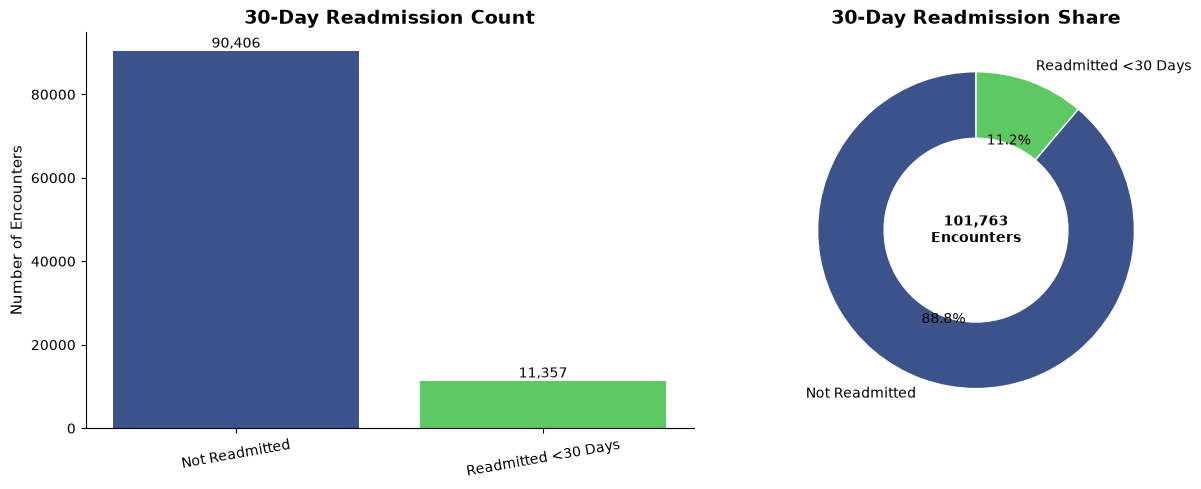

In [24]:
# Target distribution
target_counts = df["readmitted_30d"].value_counts().sort_index()
labels = ["Not Readmitted", "Readmitted <30 Days"]
plot_colors = [cmap(0.25), cmap(0.75)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart — counts
bars = axes[0].bar(
    labels,
    target_counts.values,
    color=plot_colors
)

axes[0].set_title("30-Day Readmission Count")
axes[0].set_ylabel("Number of Encounters")
axes[0].tick_params(axis="x", rotation=10)

# Add count labels
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

# Donut chart — percentages
axes[1].pie(
    target_counts.values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=plot_colors,
    wedgeprops={"width": 0.42, "edgecolor": "white"}
)

axes[1].text(
    0, 0,
    f"{len(df):,}\nEncounters",
    ha="center",
    va="center",
    fontweight="bold"
)

axes[1].set_title("30-Day Readmission Share")

plt.tight_layout()
plt.show()

Of the 101,763 hospital encounters, 11,357 (11.2%) resulted in readmission within 30 days, while 90,406 (88.8%) did not.

The target variable is therefore imbalanced, with 30-day readmissions representing approximately one in nine encounters. This imbalance should be considered during predictive modeling and model evaluation.

## 3.3 Univariate Analysis

The distributions of selected patient, healthcare utilization, clinical, and encounter characteristics are examined to understand the population represented in the dataset.

### 3.3.1 Patient Characteristics

Age, gender, and race distributions are examined to understand the demographic composition of hospital encounters.

Age distribution

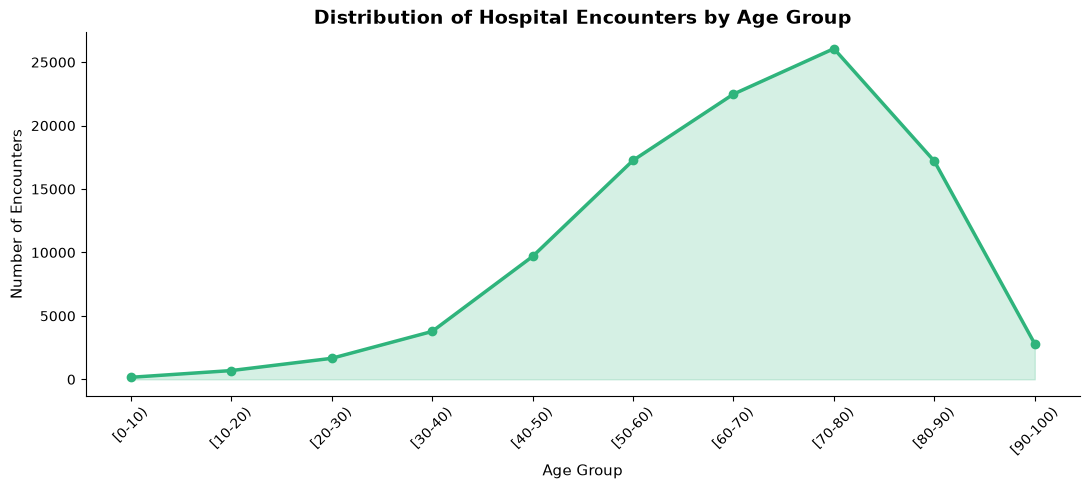

In [25]:
# Define age order
age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
]

age_counts = (
    df["age"]
    .value_counts()
    .reindex(age_order)
)

# Plot age distribution
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    age_order,
    age_counts.values,
    marker="o",
    linewidth=2.5,
    color=cmap(0.65)
)

ax.fill_between(
    age_order,
    age_counts.values,
    alpha=0.20,
    color=cmap(0.65)
)

ax.set_title("Distribution of Hospital Encounters by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Encounters")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Hospital encounters increase progressively with age and peak among patients aged 70–80 years. Most encounters are concentrated among patients aged 50–90 years, while younger age groups account for relatively few encounters.

Gender and Race Distribution 

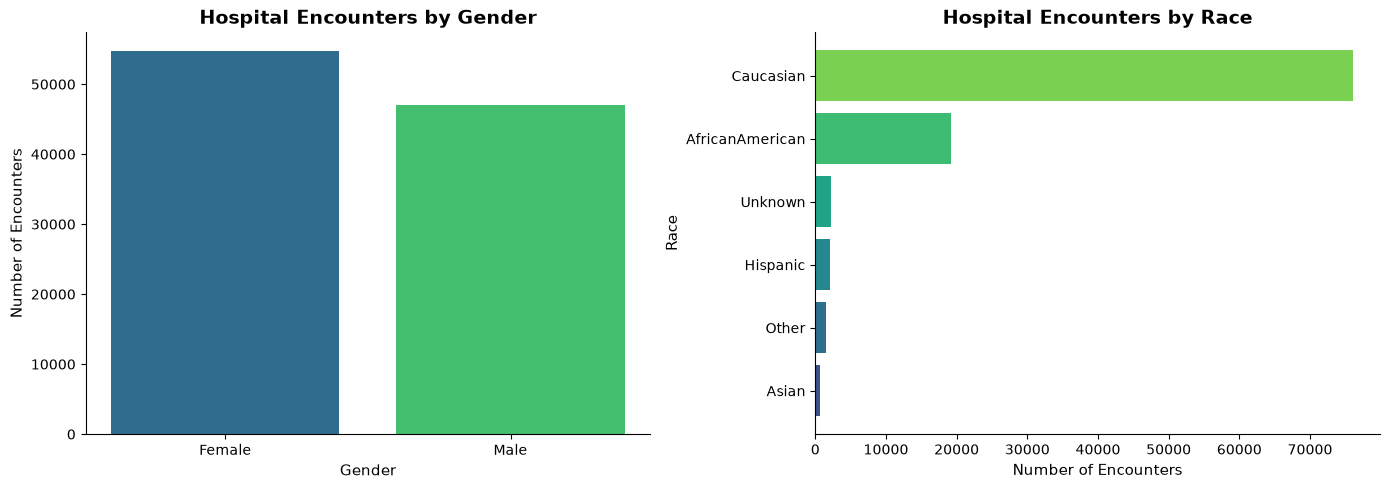

In [26]:
# Prepare distributions
gender_counts = df["gender"].value_counts()
race_counts = df["race"].value_counts().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender — vertical bars
axes[0].bar(
    gender_counts.index,
    gender_counts.values,
    color=[cmap(0.35), cmap(0.70)]
)

axes[0].set_title("Hospital Encounters by Gender")
axes[0].set_ylabel("Number of Encounters")
axes[0].set_xlabel("Gender")

# Race — horizontal bars
race_colors = cmap(np.linspace(0.25, 0.80, len(race_counts)))

axes[1].barh(
    race_counts.index,
    race_counts.values,
    color=race_colors
)

axes[1].set_title("Hospital Encounters by Race")
axes[1].set_xlabel("Number of Encounters")
axes[1].set_ylabel("Race")

plt.tight_layout()
plt.show()

Female encounters slightly exceed male encounters. The racial distribution is predominantly Caucasian, followed by African American patients, while Hispanic, Asian, other, and unknown racial categories represent substantially smaller proportions of encounters.

### 3.3.2 Healthcare Utilization

Prior inpatient, emergency, and outpatient visits are examined to understand patterns of healthcare utilization preceding the current hospital encounter.

In [27]:
utilization_cols = [
    "number_inpatient",
    "number_emergency",
    "number_outpatient"
]

df[utilization_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
number_inpatient,101763.0,0.64,1.26,0.0,0.0,0.0,1.0,21.0
number_emergency,101763.0,0.20,0.93,0.0,0.0,0.0,0.0,76.0
number_outpatient,101763.0,0.37,1.27,0.0,0.0,0.0,0.0,42.0


In [28]:
utilization_summary = pd.DataFrame({
    "No Prior Visits (%)": (df[utilization_cols].eq(0).mean() * 100).round(1),
    "At Least One Prior Visit (%)": (df[utilization_cols].gt(0).mean() * 100).round(1)
})

utilization_summary

,No Prior Visits (%),At Least One Prior Visit (%)
number_inpatient,66.5,33.5
number_emergency,88.8,11.2
number_outpatient,83.6,16.4


Prior healthcare utilization variables are highly right-skewed and concentrated at zero. Therefore, utilization is first summarized as no prior visits versus at least one prior visit to clearly show the prevalence of previous healthcare use. High-utilization values are retained because they may contain meaningful information about readmission risk.

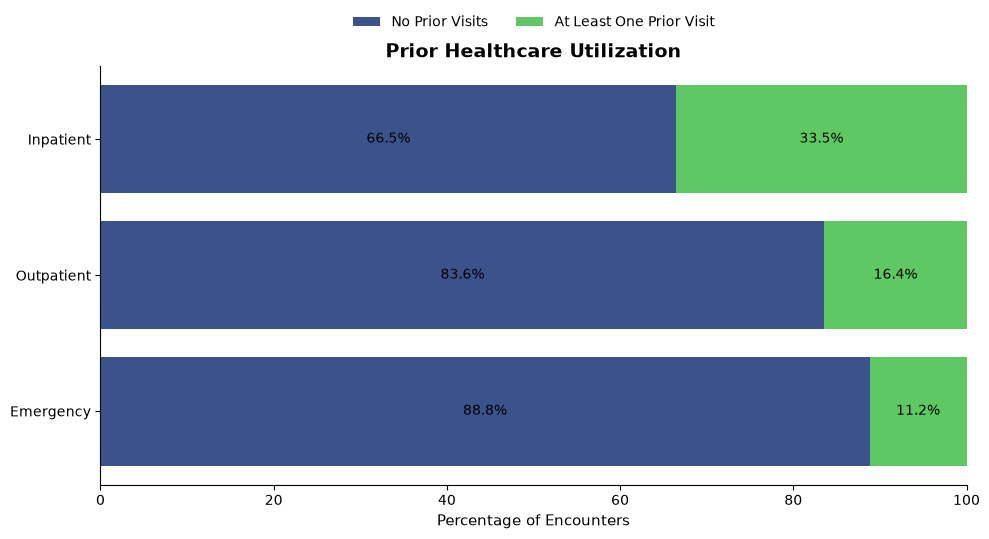

In [29]:
# Prepare data
util_plot = utilization_summary.rename(index={
    "number_inpatient": "Inpatient",
    "number_outpatient": "Outpatient",
    "number_emergency": "Emergency"
}).reindex(["Inpatient", "Outpatient", "Emergency"])

fig, ax = plt.subplots(figsize=(10, 5.5))

# Plot stacked bars
left = np.zeros(len(util_plot))

for col, color in zip(util_plot.columns, [cmap(0.25), cmap(0.75)]):
    values = util_plot[col].values

    ax.barh(
        util_plot.index,
        values,
        left=left,
        color=color,
        label=col.replace(" (%)", "")
    )

    for i, value in enumerate(values):
        ax.text(
            left[i] + value / 2,
            i,
            f"{value:.1f}%",
            ha="center",
            va="center"
        )

    left += values

# Format
ax.set(
    xlim=(0, 100),
    xlabel="Percentage of Encounters",
    ylabel="",
    title="Prior Healthcare Utilization"
)

ax.invert_yaxis()
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()

Prior healthcare utilization was limited for most encounters. Prior inpatient use was the most common, with 33.5% of encounters recording at least one inpatient visit, compared with 16.4% for outpatient visits and 11.2% for emergency visits.

This indicates that prior inpatient utilization is more prevalent than prior outpatient or emergency utilization in the study population.

### 3.3.3 Clinical and Encounter Characteristics

Selected encounter and clinical characteristics are examined to understand hospitalization intensity and patient complexity within the study population.

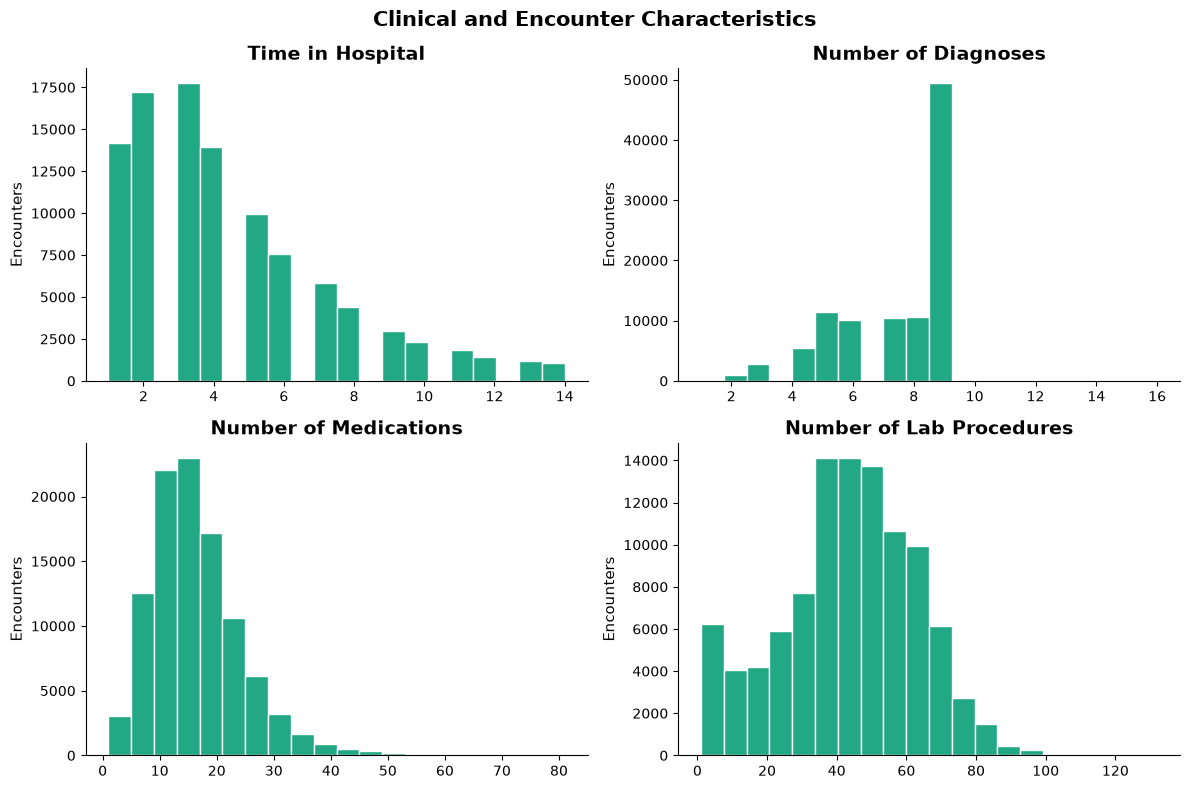

In [30]:
clinical_vars = {
    "time_in_hospital": "Time in Hospital",
    "number_diagnoses": "Number of Diagnoses",
    "num_medications": "Number of Medications",
    "num_lab_procedures": "Number of Lab Procedures"
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (col, title) in zip(axes, clinical_vars.items()):
    ax.hist(
        df[col],
        bins=20,
        color=cmap(0.60),
        edgecolor="white"
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Encounters")

fig.suptitle(
    "Clinical and Encounter Characteristics",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

The clinical and encounter variables show distinct distribution patterns:

- **Time in hospital:** Encounters are concentrated at shorter lengths of stay, particularly within the first few days, with frequency declining as hospitalization duration increases. The distribution is right-skewed, indicating that prolonged hospital stays occur less frequently.

- **Number of diagnoses:** Encounters are concentrated toward the upper end of the recorded diagnosis range, with a pronounced peak around nine diagnoses. This suggests substantial documented clinical complexity among many encounters, although the concentration at nine may also reflect characteristics of how diagnoses were recorded in the dataset.

- **Number of medications:** Most encounters involve moderate medication counts, while progressively fewer encounters involve very large numbers of medications. The right-skewed distribution indicates a smaller subgroup with substantially higher medication burden.

- **Number of laboratory procedures:** Laboratory utilization is more broadly distributed than the other measures, with most encounters concentrated around approximately 30–70 procedures and fewer encounters at very high procedure counts.

Overall, the distributions indicate considerable variation in hospitalization intensity and clinical complexity across encounters. Whether these characteristics are associated with 30-day readmission will be examined in the bivariate analysis.

### 3.3.4 Admission Type

The distribution of admission types is examined to understand the circumstances under which patients entered hospital care.

In [31]:
[col for col in df.columns if "admission" in col.lower()]

['admission_type_id',
 'admission_source_id',
 'admission_type',
 'admission_source']

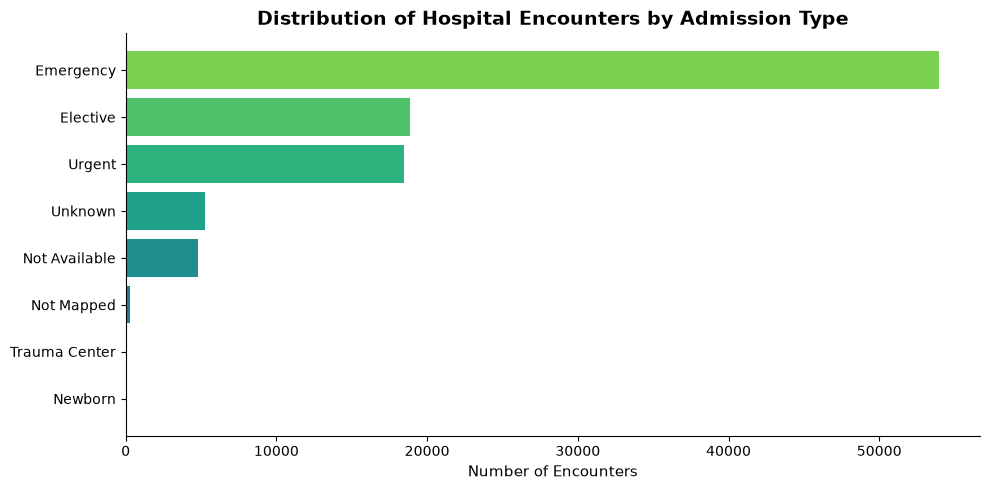

In [32]:
# Admission type distribution
admission_counts = df["admission_type"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    admission_counts.index,
    admission_counts.values,
    color=cmap(np.linspace(0.25, 0.80, len(admission_counts)))
)

ax.set(
    title="Distribution of Hospital Encounters by Admission Type",
    xlabel="Number of Encounters",
    ylabel=""
)

plt.tight_layout()
plt.show()

Emergency admissions dominate the encounter distribution, accounting for substantially more hospital encounters than any other admission type. Elective and urgent admissions form the next largest groups and occur at relatively similar frequencies.

Unknown and unavailable admission types represent a smaller but noticeable proportion of encounters, while admissions classified as not mapped, trauma center, and newborn are rare.

The distribution indicates that hospital encounters in this population are predominantly associated with emergency, urgent, and elective admission pathways. The strong concentration in emergency admissions highlights the largely acute-care nature of the study population.